# AMI wavefront eigenbasis from the amigo model

Builds a pupil-wide OPD eigenbasis for AMI with Milo's `dlux_eigenmode_toolkit/ami_wavefront_modes.py` (imported unchanged),
using the full amigo forward model (optics, detector, ramp, read) in place of a plain dLux telescope.

- **Parameters:** one OPD coefficient (nm) per pupil pixel on the support: the fitted apertures of `STATE_NAME` (its
  `distortion` and `primary_beam`) grown by `OVERSIZE`. Centring the support on the fitted hole positions, not the nominal
  ones, is what lets `OVERSIZE` be much smaller than 1.2.
- **Reference point:** the support is also the transmitting aperture. Detector, ramp and read parameters, positions, fluxes,
  spectra and defocus come from the state. `REFERENCE = "state"` also loads its fitted Zernike aberrations; `"flat"`
  linearises about a flat wavefront.
- **Fisher matrix:** `sum J.T C^-1 J` over the chosen calibrator exposures, where the data are the slopes on good pixels and
  `C` is the diagonal of each exposure's measured slope covariance (what amigo's likelihood uses by default).
- **Modes:** leading eigenvectors by Lanczos, never forming the matrix. Global piston is projected out; global tip / tilt /
  defocus are marginalised within each exposure (`MARGINALISE`), since amigo fits a position per exposure and a defocus per
  filter.
- **Output:** `(K, 1024, 1024)`, NaN outside the support, unit sum of squares per mode: the layout
  `AMIOptics(eigen_basis=...)` reads. The NaN pattern is the support amigo will use. Eigenvalues are saved next to it.

Needs the amigo `retrain` branch with `file_eigen_support`, so that amigo takes an eigenbasis's support from the file itself.

In [1]:
import jax

jax.config.update("jax_enable_x64", True)

import jax.numpy as np
import numpy as onp
from jax import vmap

import zodiax as zdx
import dLux.utils as dlu
import amigo
from amigo import optical_models as om

import matplotlib.pyplot as plt
import matplotlib as mpl
import scienceplots
import os
import sys
import time

sys.path.insert(0, "dlux_eigenmode_toolkit")
from ami_wavefront_modes import MaskedPixelOPD, model_fisher_matvec, leading_modes, mode_maps

plt.style.use(["science", "bright", "no-latex"])
plt.rcParams["image.cmap"] = "inferno"
plt.rcParams["font.family"] = "serif"
plt.rcParams["image.origin"] = "lower"
plt.rcParams["font.size"] = 8

seismic = mpl.colormaps["seismic"]
seismic.set_bad("k", 0.5)

load_dict = lambda x: onp.load(f"{x}", allow_pickle=True).item()

assert hasattr(om, "crop_windows") and hasattr(om, "file_eigen_support"), (
    "this amigo needs sparse propagation and eigen_basis files that carry their own support: use the `retrain` branch "
    "with the file_eigen_support change"
)
print(jax.local_devices()[0].device_kind, "| amigo", amigo.__version__, amigo.__file__)

NVIDIA H200 | amigo 0.0.10 /home/dgxuser/max/code/amigo/src/amigo/__init__.py


In [2]:
from socket import gethostname

if gethostname() in ("maxs-mbp-14.shared.sydney.edu.au", "Maxs-MacBook-Pro-14.local"):
    data_dir = "/Volumes/research-data/PRJ-PAT/max/data/JWST/"
    amigo_files_path = "/Volumes/research-data/PRJ-PAT/max/data/amigo_files/v_0.0.11"
elif gethostname().startswith("max-"):
    data_dir = "/home/dgxuser/max/data/JWST/"
    amigo_files_path = "/home/dgxuser/max/data/amigo_files/v_0.0.11"
else:
    data_dir = "/fred/oz440/max/data/JWST/"
    amigo_files_path = "/fred/oz440/max/data/amigo_files/v_0.0.11"
print(f"amigo_files_path: {amigo_files_path}")

# ---- knobs -----------------------------------------------------------------
STATE_NAME = "final_statev46"  # detector / ramp / read parameters, positions, fluxes, spectra, defocus
REFERENCE = "state"  # wavefront the Fisher matrix is linearised about: "state" (fitted aberrations) or "flat"
OUT_NAME = f"eigenbasis_amigo_{REFERENCE}"  # written to amigo_files_path as OUT_NAME.npy (+ _values.npy)
K = 300  # number of modes

FILTERS = ["F380M", "F430M", "F480M"]
N_PER_FILTER = 1  # CAL4481 exposures per filter (5 available each)
POS1_ONLY = True

F2F = 0.80
OVERSIZE = 1.05  # the support is the state's fitted apertures grown by this factor (room for the metrology to move)
STATE_OVERSIZE = 1.2  # oversize of the Zernike basis the state was fitted with
RADIAL_ORDERS = 7  # Zernike basis the state was fitted with (7 -> 28 Noll modes)
MARGINALISE = ["tip", "tilt", "defocus"]  # global terms marginalised per exposure; [] keeps them (piston is always removed)

TOL = 1e-7  # Lanczos tolerance
SAVE = True

COMPARE = "eigenbasis_v1"  # existing basis for section 6, or None to skip
N_COMPARE = 20  # one Fisher-vector product per mode

assert REFERENCE in ("state", "flat")
state = load_dict(os.path.join(amigo_files_path, STATE_NAME + ".npy"))

amigo_files_path: /home/dgxuser/max/data/amigo_files/v_0.0.11


## 1. Exposures
The CAL4481 calibrator exposures, loaded as in `retrain.ipynb` (static bad-pixel map).

In [3]:
from importlib import resources
from amigo.files import get_files
from amigo.misc import get_pos
from amigo.model_fits import PointFit

badpix = onp.array(onp.load(resources.files("amigo") / "data" / "badpix.npy"), dtype=int)

files = get_files(os.path.join(data_dir, "4481/calslope/"), "nis_calslope", IS_PSF=True)
files.sort(key=lambda f: (f[0].header["FILTER"], f[0].header["FILENAME"]))
chosen = []
for filt in FILTERS:
    matched = [f for f in files if f[0].header["FILTER"] == filt and (not POS1_ONLY or get_pos(f) == "POS1")]
    chosen += matched[:N_PER_FILTER]
for f in chosen:
    f["BADPIX"].data = badpix

exposures = [PointFit(f) for f in chosen]
_ = [f.close() for f in files]
for exp in exposures:
    print(exp.key, exp.filter, exp.star, f"ngroups {exp.ngroups}", f"nints {exp.nints}")

04481_001_04_03_1 F380M HD-41094 ngroups 11 nints 1060
04481_001_06_03_1 F430M HD-41094 ngroups 20 nints 905
04481_001_02_03_1 F480M HD-41094 ngroups 30 nints 760


## 2. amigo model with a per-pixel OPD
The support is the state's fitted aperture with its flat-to-flat scaled by `OVERSIZE`, built by amigo's own
`DynamicApertureMask`, so it follows the fitted hole positions and shapes. `PixelOPDMask` is amigo's static aperture mask with
that support as its transmission, plus Milo's `MaskedPixelOPD` on its transmitting pixels. The pixel OPD is added in the same
per-hole windows as amigo's own aberration basis, so the modes come out in the frame `AMIOptics(eigen_basis=...)` expects.

The mask's Zernike basis is the one the state was fitted with (nominal hexagons at `F2F × STATE_OVERSIZE`, `RADIAL_ORDERS`), so
with `REFERENCE = "state"` the fitted aberrations drop straight in; with `"flat"` they stay at zero.

fitted aperture vs the state's saved transmission: 3.3e-16
fitted aperture inside the support: True
106137 active pupil pixels
support fits the per-hole windows; pixels per hole: [15158 15120 15177 15160 15217 15222 15083]


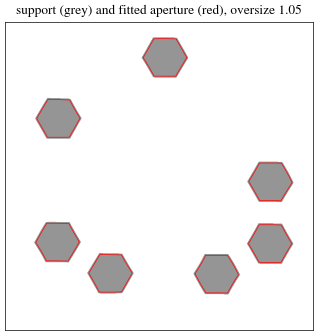

In [4]:
from amigo.core_models import AmigoModel
from amigo.detector_models import LinearDetector
from amigo.ramp_models import NonLinearRamp
from amigo.read_models import ReadModel
from retrain_fns import nn_setup_options


class PixelOPDMask(om.StaticApertureMask):
    pixel_opd: MaskedPixelOPD

    def __init__(self, transmission, **kwargs):
        super().__init__(**kwargs)
        self.transmission = np.asarray(transmission)
        self.pixel_opd = MaskedPixelOPD(transmission)

    def sparse_fields(self, npixels, diameter):
        mask, opd, amp, centers = super().sparse_fields(npixels, diameter)
        return mask, opd + om.crop_windows(self.pixel_opd.opd, self.corners, self.size), amp, centers

    def __call__(self, wavefront):
        return super().__call__(wavefront).add_opd(self.pixel_opd.opd)


NPIX, DIAMETER = 1024, 6.603464

# the state's fitted aperture, and the same aperture grown by OVERSIZE: the support
fitted = om.DynamicApertureMask(f2f=F2F, distortion_orders=3, aberration_orders=1, diameter=DIAMETER, npixels=NPIX)
fitted = fitted.set(
    ["transformation.distortion", "primary_beam"], [np.asarray(state["distortion"]), np.asarray(state["primary_beam"])]
)
aperture = onp.asarray(fitted.calc_mask(NPIX, DIAMETER))
transmission = onp.asarray(fitted.set("f2f", np.asarray(F2F * OVERSIZE)).calc_mask(NPIX, DIAMETER))
print(f"fitted aperture vs the state's saved transmission: {onp.abs(aperture - state['transmission']).max():.1e}")
print("fitted aperture inside the support:", bool((transmission > 0)[aperture > 0].all()))

# Zernike basis as the state was fitted with (f2f * STATE_OVERSIZE, nominal positions); transmission is the support
pupil_mask = PixelOPDMask(
    transmission, f2f=F2F * STATE_OVERSIZE, oversize=1.0, aberration_orders=RADIAL_ORDERS, amplitude_orders=4
)
optics = om.AMIOptics(pupil_mask=pupil_mask, sparse=True)
pixel_opd = pupil_mask.pixel_opd
q0 = pixel_opd.coefficients
print(f"{q0.size} active pupil pixels")

model = AmigoModel(
    exposures=exposures,
    optics=optics,
    detector=LinearDetector(),
    ramp_model=NonLinearRamp(**nn_setup_options[0]),
    read=ReadModel(per_pixel_dark=True),
)

# populate from the state: global detector / ramp / read terms, then the per-exposure parameters
for key in ["nn_weights", "FF", "non_linearity", "sigma", "dark_current"]:
    model = model.set(key, np.asarray(state[key]))
# with REFERENCE = "state" the fitted Zernike aberrations (one key per program and filter) are loaded too
for key in ["positions", "fluxes", "defocus", "spectra"] + (["aberrations"] if REFERENCE == "state" else []):
    current = model.get(key)
    missing = [k for k in current if k not in state[key]]
    if missing:
        print(f"{key}: not in the state, left at their initial values: {missing}")
    model = model.set(key, {k: np.asarray(state[key].get(k, v)) for k, v in current.items()})

# the support has to fit inside amigo's per-hole windows (raises if not)
coords = dlu.pixel_coords(NPIX, DIAMETER)
support = om.file_eigen_support(onp.where(transmission > 0, 1.0, onp.nan), pupil_mask.corners, pupil_mask.size)
print(f"support fits the per-hole windows; pixels per hole: {support.sum((1, 2))}")

fig, ax = plt.subplots(figsize=(4, 4))
ax.imshow(onp.where(transmission > 0, 1.0, onp.nan), cmap="Greys", vmin=0, vmax=2)
ax.contour(aperture, levels=[0.5], colors="r", linewidths=0.5)
ax.set(title=f"support (grey) and fitted aperture (red), oversize {OVERSIZE}", xticks=[], yticks=[])
plt.show()

## 3. Fisher operator
The toolkit calls `model.set(key, q).model()` on each model in a list. `ExposureModel` gives one amigo exposure that interface:
`.model()` returns the slopes on good pixels divided by their standard deviation, so the toolkit's `variance_fn` is just 1.

Global tip / tilt / defocus are marginalised as in Milo's `vega_group_fishers.ipynb`, but separately for each exposure before
summing: with `D` the orthonormalised global terms, exposure `i` contributes `F_i - B_i C_i^-1 B_i.T`, where `B_i = F_i D` and
`C_i = D.T F_i D`. This is the information left once that exposure's own tip / tilt / defocus are fitted freely. `D` is in the
null space of the result, so the modes come out orthogonal to those terms. Global piston is projected out by `leading_modes`.

In [5]:
class ExposureModel(zdx.Base):
    amigo: AmigoModel
    exposure: PointFit
    weight: jax.Array

    def __init__(self, amigo, exposure):
        self.amigo = amigo
        self.exposure = exposure
        self.weight = 1 / np.sqrt(vmap(np.diag)(exposure.to_vec(exposure.cov)))  # (n_pix, n_slopes)

    def model(self):
        return self.exposure.to_vec(self.exposure(self.amigo)) * self.weight


models = [ExposureModel(model, exp) for exp in exposures]
key = "amigo.optics.pupil_mask.pixel_opd.coefficients"

# reference check: the oversized-aperture model is not a fit, so chi2 is large (less so with the fitted aberrations)
for m in models:
    mu = m.model()
    data = m.exposure.to_vec(m.exposure.slopes) * m.weight
    print(f"{m.exposure.filter}: {mu.size} data points, finite {bool(np.isfinite(mu).all())}, "
          f"reduced chi2 at the reference {float(((mu - data) ** 2).mean()):.0f}")


# one Fisher operator per exposure, so each can be marginalised over its own global terms
F_exp = [model_fisher_matvec(m, key, q0, lambda mu: np.ones_like(mu)) for m in models]

# global terms over the active pixels, orthonormalised with piston first; D drops the piston column
xy = onp.asarray(coords).reshape(2, -1)[:, onp.asarray(pixel_opd.indices)]
terms = {"tip": xy[0], "tilt": xy[1], "defocus": (xy**2).sum(0)}
Q = onp.linalg.qr(onp.stack([onp.ones(q0.size)] + [terms[t] for t in MARGINALISE], 1))[0]
D = Q[:, 1:]

t = time.time()
B = [onp.stack([onp.asarray(F_i(D[:, j])) for j in range(D.shape[1])], 1) if D.shape[1] else onp.zeros((q0.size, 0))
     for F_i in F_exp]  # F_i D
C = [D.T @ B_i for B_i in B]
C_inv = [onp.linalg.pinv(0.5 * (C_i + C_i.T), rcond=1e-10, hermitian=True) for C_i in C]
print(f"nuisance blocks (with compile): {time.time() - t:.1f} s")
for m, B_i, C_i in zip(models, B, C):
    if D.shape[1]:
        print(f"{m.exposure.filter}: sigma of global {MARGINALISE} (nm, unit-norm): "
              f"{onp.round(1 / onp.sqrt(onp.diag(C_i)), 3)}")

n_matvec = 0


def F_marg(v):
    global n_matvec
    n_matvec += 1
    v = onp.asarray(v, dtype=float)
    out = onp.zeros(q0.size)
    for F_i, B_i, Ci in zip(F_exp, B, C_inv):
        out += onp.asarray(F_i(v)) - B_i @ (Ci @ (B_i.T @ v))
    return out


# timing and symmetry
rng = onp.random.default_rng(0)
a, b = rng.normal(size=(2, q0.size))
t = time.time()
Fa, Fb = F_marg(a), F_marg(b)
print(f"marginalised Fisher-vector product: {(time.time() - t) / 2:.1f} s | "
      f"symmetry b.Fa / a.Fb = {float(b @ Fa) / float(a @ Fb):.12f}")
if D.shape[1]:
    print(f"global terms in the null space: |F D| / |F a| = "
          f"{max(onp.linalg.norm(F_marg(D[:, j])) for j in range(D.shape[1])) / onp.linalg.norm(Fa):.2e}")

F380M: 57150 data points, finite True, reduced chi2 at the reference 105
F430M: 108585 data points, finite True, reduced chi2 at the reference 40
F480M: 165735 data points, finite True, reduced chi2 at the reference 22
nuisance blocks (with compile): 45.0 s
F380M: sigma of global ['tip', 'tilt', 'defocus'] (nm, unit-norm): [8.754 8.455 8.12 ]
F430M: sigma of global ['tip', 'tilt', 'defocus'] (nm, unit-norm): [10.39  10.068 10.361]
F480M: sigma of global ['tip', 'tilt', 'defocus'] (nm, unit-norm): [11.938 11.614 12.88 ]
marginalised Fisher-vector product: 1.1 s | symmetry b.Fa / a.Fb = 1.000000000000
global terms in the null space: |F D| / |F a| = 2.04e-16


## 4. Leading modes
Lanczos needs at least `2K + 1` Fisher-vector products, usually a few times that.
`residuals` are `|Fv - λv| / λ` per mode; they should sit near `TOL`.

In [ ]:
n_matvec = 0
t = time.time()
values, vectors, residuals = leading_modes(F_marg, q0.size, k=K, remove_piston=True, tol=TOL)
print(f"{K} modes: {n_matvec} Fisher-vector products, {(time.time() - t) / 60:.1f} min")
print(f"largest residual {residuals.max():.2e}")
print(f"orthonormality error {onp.abs(vectors.T @ vectors - onp.eye(K)).max():.2e}")
print(f"largest overlap with global piston / {MARGINALISE} {onp.abs(Q.T @ vectors).max():.2e}")

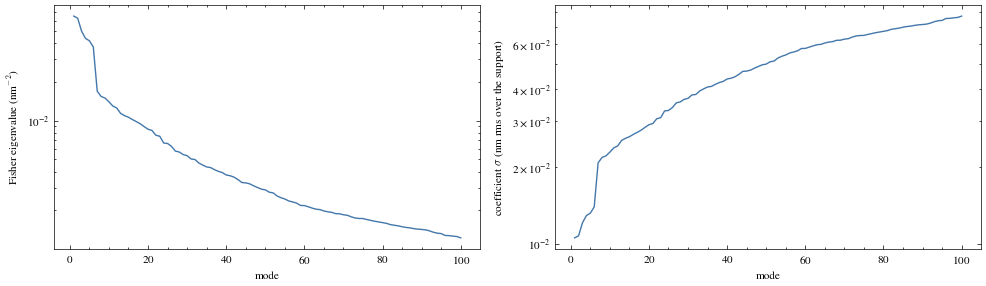

In [ ]:
# sigma: 1-sigma uncertainty of a mode's coefficient (nm) for a unit-norm mode, from these exposures alone.
# Dividing by sqrt(N_active) gives it for the RMS-1 scaling amigo uses.
sigma = 1 / onp.sqrt(values)

fig, ax = plt.subplots(1, 2, figsize=(10, 3))
ax[0].semilogy(onp.arange(1, K + 1), values)
ax[0].set(xlabel="mode", ylabel="Fisher eigenvalue (nm$^{-2}$)")
ax[1].semilogy(onp.arange(1, K + 1), sigma / onp.sqrt(q0.size))
ax[1].set(xlabel="mode", ylabel="coefficient $\\sigma$ (nm rms over the support)")
plt.tight_layout()
plt.show()

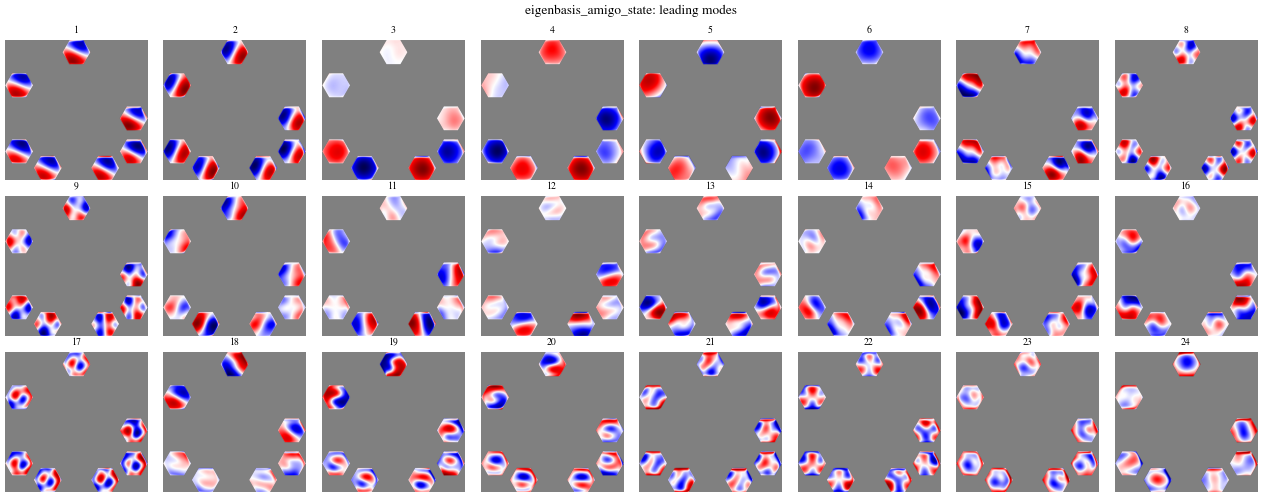

In [ ]:
maps = mode_maps(pixel_opd, vectors)  # (K, 1024, 1024), NaN outside the support


def show_modes(maps, n=24, ncols=8, title=None):
    n = min(n, len(maps))
    rows = (n + ncols - 1) // ncols
    ys, xs = onp.where(onp.isfinite(maps[0]))
    sl = (slice(ys.min(), ys.max() + 1), slice(xs.min(), xs.max() + 1))
    fig, axes = plt.subplots(rows, ncols, figsize=(1.6 * ncols, 1.7 * rows), squeeze=False)
    for i, ax in enumerate(axes.flat):
        ax.set_axis_off()
        if i < n:
            m = maps[i][sl]
            v = onp.nanmax(onp.abs(m))
            ax.imshow(m, cmap=seismic, vmin=-v, vmax=v)
            ax.set_title(f"{i + 1}", fontsize=7)
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


show_modes(maps, title=f"{OUT_NAME}: leading modes")

## 5. Save
`OUT_NAME.npy` is the basis in the layout amigo reads; `OUT_NAME_values.npy` holds the eigenvalues. The last line loads the file
back through amigo's own `AMIOptics(eigen_basis=...)`, which takes the support from the file and raises if it doesn't fit the per-hole windows.

In [ ]:
out_path = os.path.join(amigo_files_path, OUT_NAME + ".npy")
if SAVE:
    if os.path.exists(out_path):
        raise FileExistsError(f"{out_path} already exists: change OUT_NAME or remove it")
    onp.save(out_path, maps)
    onp.save(os.path.join(amigo_files_path, OUT_NAME + "_values.npy"), values)
    print("saved:", out_path)

    check = om.AMIOptics(eigen_basis=out_path, static=False, sparse=True)
    print("amigo loads it:", check.pupil_mask.abb_basis.shape, "coefficients", check.pupil_mask.abb_coeffs.shape)
else:
    print("SAVE = False, nothing written")

## 6. Eigenvalues of an existing basis
For modes that were made elsewhere, `v.T F v` (with the marginalised `F`) gives each one's Fisher information under this model (a Rayleigh quotient: the
true eigenvalue only if `v` is an eigenvector of this `F`). One Fisher-vector product per mode.

The existing basis lives on a larger support, so its modes are first cut to this one and renormalised.

The overlap matrix `|V_old.T V_new|` shows how much of each existing mode lies along each new one.

In [ ]:
if COMPARE is not None:
    E = onp.load(os.path.join(amigo_files_path, COMPARE + ".npy"), mmap_mode="r")
    n_c = min(N_COMPARE, len(E))
    idx = onp.asarray(pixel_opd.indices)
    old_support = onp.isfinite(E[0])
    print(f"{COMPARE}: covers {old_support.reshape(-1)[idx].mean():.1%} of this support")
    # the existing modes restricted to this support (they live on a larger one), renormalised
    V_old = onp.stack([onp.nan_to_num(onp.asarray(E[i])).reshape(-1)[idx] for i in range(n_c)], 1)
    print("fraction of each mode's sum of squares inside this support:", onp.round((V_old**2).sum(0), 3))
    V_old /= onp.linalg.norm(V_old, axis=0)
    V_old -= V_old.mean(0)  # global piston, as leading_modes removes it
    rayleigh = onp.array([V_old[:, i] @ F_marg(V_old[:, i]) for i in range(n_c)])

    fig, ax = plt.subplots(1, 2, figsize=(10, 3.5))
    ax[0].semilogy(onp.arange(1, K + 1), values, label=OUT_NAME)
    ax[0].semilogy(onp.arange(1, n_c + 1), rayleigh, "o", ms=3, label=f"{COMPARE} (Rayleigh quotient)")
    ax[0].set(xlabel="mode", ylabel="Fisher information (nm$^{-2}$)")
    ax[0].legend()
    im = ax[1].imshow(onp.abs(V_old.T @ vectors[:, : max(n_c, 40)]), vmin=0, vmax=1, aspect="auto", origin="upper")
    ax[1].set(xlabel=f"{OUT_NAME} mode", ylabel=f"{COMPARE} mode", title="overlap")
    fig.colorbar(im, ax=ax[1])
    plt.tight_layout()
    plt.show()

    # fraction of each existing mode inside the span of the K new modes
    print("fraction of each mode inside the new basis:", onp.round(((V_old.T @ vectors) ** 2).sum(1), 3))